#header#
##subheader##
**bold**  * *italic* *  ***all bold and italic***

In [4]:
#import packages and dataset
import pandas as pd 
import scipy.stats as stats
import os
import sys
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from scipy.stats import norm, cauchy
import numpy as np

df = pd.read_parquet('/Users/laurencadle/Downloads/singlesites.parquet')
df.head(10)
energy = df['Energy'].to_numpy()

In [5]:
#super compressed code!!
from spurs_2026.spurs_funcs import *

Gaussian: mu=439.531±0.108, width=1.490±0.156, c=-7.862±5.263, d=5648.926±2287.140


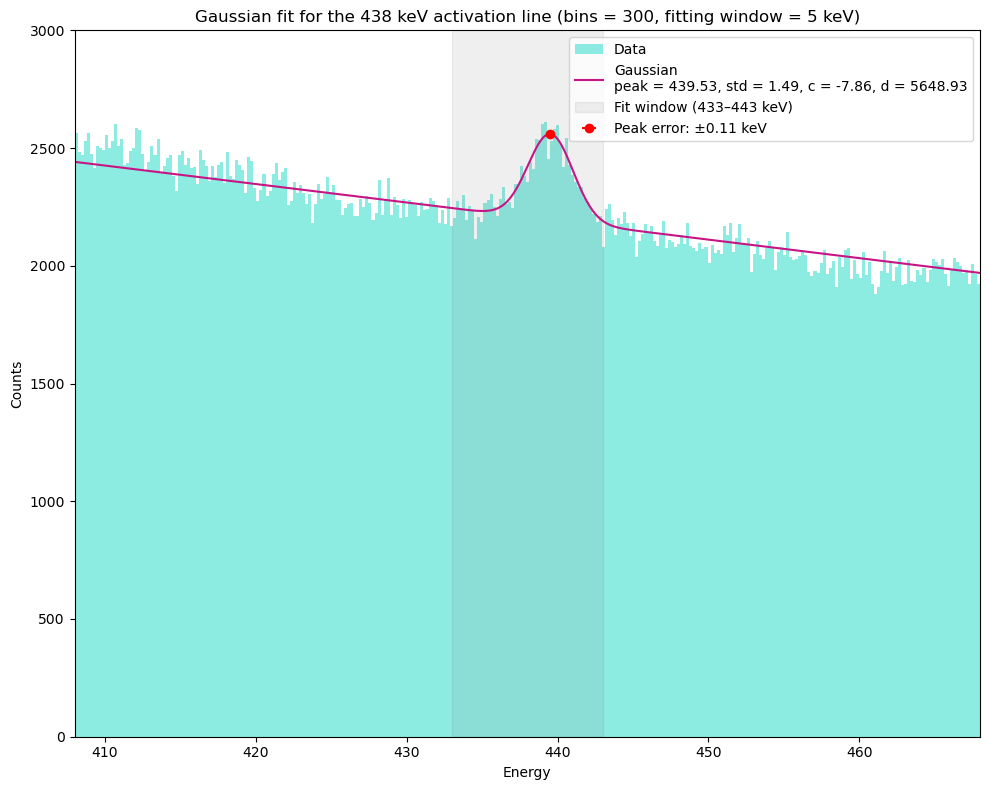

In [10]:
#ten line code!!
line = 438
N = 300
fitting_window = 5

lower_bound, upper_bound, fitted_lower, fitted_upper = get_bounds(line)
counts, bin_edges, bin_width, bin_centers = bin_sorting(N, energy, lower_bound, upper_bound)
slope_val = slope(bin_edges[-1], bin_edges[0], counts[-1], counts[0])
peak_mask = get_masks(fitted_lower, fitted_upper, bin_centers)
popt, pcov, p_err = fit_peak(gaussian_func, line, counts, peak_mask, bin_centers, slope_val, fitted_lower, fitted_upper)
print(f"Gaussian: mu={popt[0]:.3f}±{p_err[0]:.3f}, width={popt[1]:.3f}±{p_err[1]:.3f}, "f"c={popt[2]:.3f}±{p_err[2]:.3f}, d={popt[3]:.3f}±{p_err[3]:.3f}")
x1, fitted_model_g = plot_gaussian(line, N, p_err, counts, bin_edges, popt, lower_bound, upper_bound, fitted_lower, fitted_upper, fitting_window, ylim=(0, 3000))

#574, 1107, 198, 175, 596, 93
#changes to bins: 25, 50, 100, 300, 500
#changes to fitting windows: 5, 8, 10, 20, 30

#mu is the peak position, and this is what i want the error on

In [17]:
#p_err/sigma for 438, 300
line = 438
N = 300
print("Gaussian statistics and errors:")

lower_bound, upper_bound, fitted_lower, fitted_upper = get_bounds(line)
counts, bin_edges, bin_width, bin_centers = bin_sorting(N, energy, lower_bound, upper_bound)
slope_val = slope(bin_edges[-1], bin_edges[0], counts[-1], counts[0])
peak_mask = get_masks(fitted_lower, fitted_upper, bin_centers)
popt, pcov, p_err = fit_peak(gaussian_func, line, counts, peak_mask, bin_centers, slope_val, fitted_lower, fitted_upper)
print(f"Gaussian: mu={popt[0]:.3f}±{p_err[0]:.3f}, width={popt[1]:.3f}±{p_err[1]:.3f}, "f"c={popt[2]:.3f}±{p_err[2]:.3f}, d={popt[3]:.3f}±{p_err[3]:.3f}")

print("p_err of peak:", p_err[0]) #peak
print("p_err of sigma:", p_err[1]) #sigma

Gaussian statistics and errors:
Gaussian: mu=439.531±0.108, width=1.490±0.156, c=-7.862±5.263, d=5648.926±2287.140
p_err of peak: 0.10769384201806415
p_err of sigma: 0.15551491290726485


In [18]:
#p_err / c for 438, 500
line = 438
N = 500
print("Gaussian statistics and errors:")

lower_bound, upper_bound, fitted_lower, fitted_upper = get_bounds(line) #inside
counts, bin_edges, bin_width, bin_centers = bin_sorting(N, energy, lower_bound, upper_bound) #outside
slope_val = slope(bin_edges[-1], bin_edges[0], counts[-1], counts[0]) #outside
peak_mask = get_masks(fitted_lower, fitted_upper, bin_centers) #inside
popt, pcov, p_err = fit_peak(gaussian_func, line, counts, peak_mask, bin_centers, slope_val, fitted_lower, fitted_upper) #inside
print(f"Gaussian: mu={popt[0]:.3f}±{p_err[0]:.3f}, width={popt[1]:.3f}±{p_err[1]:.3f}, "f"c={popt[2]:.3f}±{p_err[2]:.3f}, d={popt[3]:.3f}±{p_err[3]:.3f}")

print("p_err of peak:", p_err[0])
print("p_err of sigma:", p_err[1])

Gaussian statistics and errors:
Gaussian: mu=439.536±0.140, width=1.563±0.203, c=-5.715±4.094, d=3816.564±1778.192
p_err of peak: 0.14019344877257978
p_err of sigma: 0.20271157205963103


In [19]:
#find delta c for 300 and 500
c_500 = 5.715
c_300 = -7.862
delta_c = c_500 - c_300
print("delta_c:", delta_c)

#find c +/- 3deltac for 300 
c_300_lower = c_300 - 3 * delta_c
c_300_upper = c_300 + 3 * delta_c
print("c_300_lower:", c_300_lower)
print("c_300_upper:", c_300_upper)

#find c +/- 3deltac for 500
c_500_lower = c_500 - 3 * delta_c
c_500_upper = c_500 + 3 * delta_c
print("c_500_lower:", c_500_lower)
print("c_500_upper:", c_500_upper)

#yes, there is some overlap between the c values

delta_c: 13.577
c_300_lower: -48.593
c_300_upper: 32.869
c_500_lower: -35.016000000000005
c_500_upper: 46.446


In [22]:
#building the pandas df
from spurs_2026.spurs_funcs import *
energy = df['Energy'].to_numpy()

#making a list to hold my objects <3
stored_values = []

#step 1: create a lil dictionary of the centroid values from the paper
centroid_vals = {175:174.956, 198:198.394, 438:438.634, 596:595.847}

#step 32: all the for loops!
for line in [175, 198, 438, 596]:
    lower_bound, upper_bound, _, _ = get_bounds(line)
    
    for bins in [50, 100, 200, 400]:
        counts, bin_edges, bin_width, bin_centers = bin_sorting(bins, energy, lower_bound, upper_bound)
        slope_val = slope(bin_edges[-1], bin_edges[0], counts[-1], counts[0])
        
        for fitting_window in [3, 4, 5, 8, 10]:
            _, _, fitted_lower, fitted_upper = get_bounds(line, fitting_window=fitting_window)
            peak_mask = get_masks(fitted_lower, fitted_upper, bin_centers)
            popt, pcov, p_err = fit_peak(gaussian_func, line, counts, peak_mask, bin_centers, slope_val, fitted_lower, fitted_upper)
            
            row = {
                "line": line,
                "bins": bins, 
                "fitting_window": fitting_window, 
                "bin_width": bin_width, 
                "mu": popt[0],
                "sigma": popt[1], 
                "c": popt[2], 
                "d": popt[3], 
                "A": popt[4], 
                "mu_err": p_err[0], 
                "sigma_err": p_err[1],
                "c_err": p_err[2],
                "d_err": p_err[3],
                "A_err": p_err[4],
                "exact_mu": centroid_vals[line],
                "deviation_in_centroid": (popt[0] - centroid_vals[line]) / p_err[0], 
                "A_over_A_err": popt[4] / p_err[4]
            }
            #storing all 80 rows into my empty list
            stored_values.append(row)
            
#step 4: now i need to put them in a df
stored_values_df = pd.DataFrame(stored_values)

/Users/laurencadle/spurs_2026/spurs_funcs.py:39: OptimizeWarning: Covariance of the parameters could not be estimated
  popt, pcov = curve_fit(gaussian_func, bin_centers[peak_mask], counts[peak_mask], p0=p0_gauss, bounds=([fitted_lower, 1, 3*slope_val, 0, 0], [fitted_upper, 10, 0, 1e6, np.inf]), maxfev=10000) #500 into 3 slope_val, -1e6 into 0,


In [23]:
stored_values_df.to_csv("/Users/laurencadle/spurs_2026/stored_values.csv", index=False)
stored_values_df.head(10)

,line,bins,fitting_window,bin_width,mu,sigma,c,d,A,mu_err,sigma_err,c_err,d_err,A_err,exact_mu,deviation_in_centroid,A_over_A_err
0,175,50,3,1.224490,175.392395,1.250649,-1562.686768,398342.473995,82964.783457,inf,inf,inf,inf,inf,174.956,0.000000,0.000000
1,175,50,4,1.224490,175.401586,1.358020,-1664.954521,414237.101756,95922.976305,0.037714,0.049661,126.021462,2.186015e+04,4684.624314,174.956,11.814731,20.476130
2,175,50,5,1.224490,175.372912,1.392653,-1514.469697,387364.519897,99490.301661,0.046071,0.054654,101.210853,1.764308e+04,4581.112322,174.956,9.049434,21.717499
3,175,50,8,1.224490,175.352417,1.425110,-1417.761297,369980.264564,102778.179304,0.046514,0.051507,57.889542,1.011834e+04,3899.030349,174.956,8.522545,26.359933
4,175,50,10,1.224490,175.323809,1.380464,-1253.887850,341884.142962,98012.967159,0.079638,0.085520,66.089622,1.156427e+04,6014.789535,174.956,4.618522,16.295328
5,175,100,3,0.606061,175.342688,1.046758,-416.074081,136035.964097,32491.648602,0.039107,0.057351,137.479807,2.377627e+04,2801.069319,174.956,9.887909,11.599730
6,175,100,4,0.606061,175.435732,1.268356,-862.696683,211951.969327,45906.404898,0.044821,0.059356,91.009773,1.577610e+04,2920.012490,174.956,10.703343,15.721304
7,175,100,5,0.606061,175.409826,1.304935,-781.698575,197472.663027,47806.894784,0.043443,0.051694,55.972918,9.752550e+03,2230.098299,174.956,10.446376,21.437124
8,175,100,8,0.606061,175.382108,1.341197,-703.708925,183543.648500,49646.764471,0.038042,0.041694,23.975443,4.191194e+03,1589.099324,174.956,11.201063,31.242078
9,175,100,10,0.606061,175.361931,1.313627,-638.514662,172317.353194,48165.160682,0.048491,0.052034,22.598065,3.953492e+03,1887.555697,174.956,8.371299,25.517213


In [24]:
#smallest error in mu 
for line in stored_values_df['line'].unique():
    smallest_error = stored_values_df[stored_values_df['line'] == line]['mu_err'].min()
    print(f"line {line}: smallest error in mu (peak) = {smallest_error}")

print() 

#smallest deivation in centroid
for line in stored_values_df['line'].unique():
    smallest_deviation = stored_values_df[(stored_values_df['line'] == line) & (stored_values_df['deviation_in_centroid'] != 0)]['deviation_in_centroid'].min()
    print(f"line {line}: smallest deviation in centroid = {smallest_deviation}")

line 175: smallest error in mu (peak) = 0.030062178376756267
line 198: smallest error in mu (peak) = 0.013598412626985492
line 438: smallest error in mu (peak) = 0.06729645918030627
line 596: smallest error in mu (peak) = 0.04188609194678381

line 175: smallest deviation in centroid = 4.618521548637417
line 198: smallest deviation in centroid = 2.2249758527722308
line 438: smallest deviation in centroid = 1.0719124575060974
line 596: smallest deviation in centroid = 0.8147572690553623


Gaussian: mu=175.393±0.030, width=1.295±0.036, c=-388.968±20.195, d=98321.312±3518.185


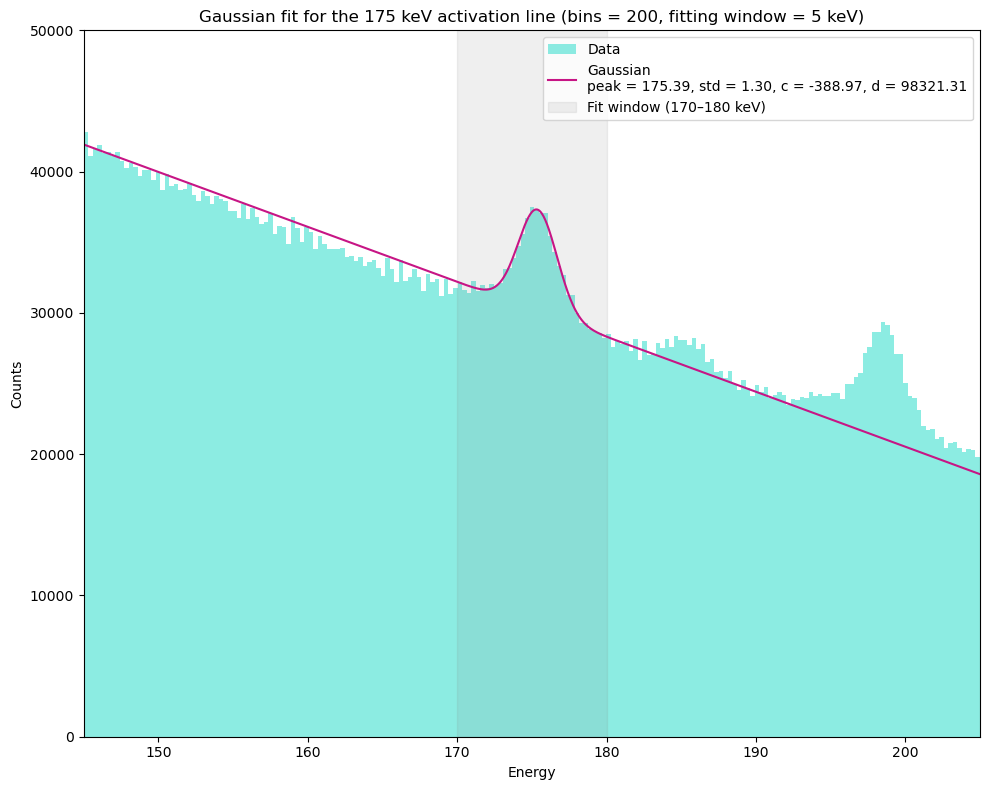

In [ ]:
#super compressed code!! 93 and 175
from spurs_2026.spurs_funcs import *
energy = df['Energy'].to_numpy()

#ten line code!!
line = 175
N = 200
fitting_window = 5

lower_bound, upper_bound, fitted_lower, fitted_upper = get_bounds(line, 30, fitting_window)
counts, bin_edges, bin_width, bin_centers = bin_sorting(N, energy, lower_bound, upper_bound)
slope_val = slope(bin_edges[-1], bin_edges[0], counts[-1], counts[0])
peak_mask = get_masks(fitted_lower, fitted_upper, bin_centers)
popt, pcov, p_err = fit_peak(quadratic_func, line, counts, peak_mask, bin_centers, slope_val, fitted_lower, fitted_upper)
print(f"Quadratic: mu={popt[0]:.3f}±{p_err[0]:.3f}, width={popt[1]:.3f}±{p_err[1]:.3f}, "f"c={popt[2]:.3f}±{p_err[2]:.3f}, d={popt[3]:.3f}±{p_err[3]:.3f}")
x1, fitted_model_g = plot_gaussian(line, N, p_err, counts, bin_edges, popt, lower_bound, upper_bound, fitted_lower, fitted_upper, fitting_window, ylim=(0, 50000))

In [ ]:
#snr counts!!
line = 511      
N = 2000
detector = 1

energy = df[df['Detector ID'] == detector]['Energy'].to_numpy()

def bounds(line, viewing=30, plotting=8):
    lower_bound = line - viewing
    upper_bound = line + viewing
    fitted_lower = line - plotting
    fitted_upper = line + plotting
    return lower_bound, upper_bound, fitted_lower, fitted_upper

def bin_sorting(N, energy):
    counts, bin_edges = np.histogram(energy, bins=np.linspace(lower_bound, upper_bound, N))
    bin_width = bin_edges[1] - bin_edges[0]
    bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
    return counts, bin_edges, bin_width, bin_centers

def slope(d2, d1, y2, y1):
    return (y2 - y1) / (d2 - d1)

def masks(fitted_lower, fitted_upper, bin_centers):
    peak_mask = (bin_centers > fitted_lower) & (bin_centers < fitted_upper)
    return peak_mask

#now lets compress the gaussian plotting function
def gaussian_func(x, mu, sigma, c, d, A):
    gaussian = 1 / (sigma*np.sqrt(2*np.pi)) * np.exp(-0.5*((x-mu)/sigma)**2)
    return gaussian * (A) + c * x + d
    
#fitting the gaussian to the peak
def fit_peak(gaussian_func, line, counts, peak_mask, bin_centers, slope_val, fitted_lower, fitted_upper):
    p0_gauss = [line, 2, slope_val, counts[peak_mask].min(), 10000]
    popt, pcov = curve_fit(gaussian_func, bin_centers[peak_mask], counts[peak_mask], p0=p0_gauss, bounds=([fitted_lower, 1, 3*slope_val, 0, 0], [fitted_upper, 10, 0, 1e6, np.inf]), maxfev=10000) #500 into 3 slope_val, -1e6 into 0,
    p_err= np.sqrt(np.diag(pcov))
    x1 = np.linspace(lower_bound, upper_bound, 1001)
    fitted_model_g = gaussian_func(x1, *popt)
    return popt, pcov, p_err, x1, fitted_model_g

def snr(popt_g, counts, bin_width):
    mu, sigma, c, d, A = popt_g
    total_counts = np.sum(counts)
    lower = mu - 1.4*sigma
    upper = mu + 1.4*sigma
    h = upper - lower
    S = (norm.cdf(upper, mu, sigma) - norm.cdf(lower, mu, sigma)) * A * total_counts * bin_width
    B = 1/2 * ((c*lower + d) + (c*upper + d)) * h
    return S / np.sqrt(S + B)

'''lower_bound, upper_bound, fitted_lower, fitted_upper = bounds(line)
counts, bin_edges, bin_width, bin_centers = bin_sorting(N, energy)
slope_val = slope(bin_edges[-1], bin_edges[0], counts[-1], counts[0])
peak_mask = masks(fitted_lower, fitted_upper, bin_centers)
popt, pcov, p_err = fit_peak(gaussian_func, line, counts, peak_mask, bin_centers, slope_val, fitted_lower, fitted_upper)
x1, fitted_model_g = plot_gaussian(line, counts, bin_edges, x1, fitted_model_g, popt, lower_bound, upper_bound, fitted_lower, fitted_upper, ylim=(12000, 30000))'''

snr_val = snr(popt_g, counts, bin_width)
print(f"Detector {detector}, {line} keV: SNR = {snr_val:.2f}")

ValueError: Each lower bound must be strictly less than each upper bound.